<a href="https://colab.research.google.com/github/lakshmigojanece/ZENDS-Communications-is-a-virtual-telecom-company/blob/main/AI_Customer_Support_Copilot_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install transformers pandas numpy


In [ ]:
#collect 20000 datasets

In [ ]:
import pandas as pd
import random
import uuid #Universally Unique Identifiers).

# Products and categories
products = {
    "Mobile Connectivity": [
        "Prepaid Basic", "Prepaid Plus", "Prepaid Unlimited",
        "Postpaid Silver", "Postpaid Gold", "Postpaid Platinum"
    ],
    "Home & Office Internet": [
        "ZENDFiber Home 100 Mbps", "ZENDFiber Home 300 Mbps", "ZENDFiber Home 1 Gbps",
        "ZENDOffice Net 200", "ZENDOffice Net 500", "ZENDOffice Net 1G"
    ],
    "Business Connectivity": [
        "ZENDBiz Connect 100", "ZENDBiz Connect 500", "ZENDBiz Connect 1G",
        "ZENDEnterprise Ultra", "ZENDEnterprise Dedicated"
    ],
    "Cloud & Data Center Services": [
        "ZENDCloud VM Basic", "ZENDCloud VM Pro", "ZENDCloud VM Enterprise",
        "ZENDStorage 1TB", "ZENDStorage 10TB", "ZENDArchive Storage"
    ],
    "IoT & Smart Solutions": [
        "ZENDSmart Traffic", "ZENDSmart Lighting", "ZENDSmart Parking",
        "ZENDIndustrial Sensor", "ZENDFleet IoT"
    ]
}

countries = ["USA", "India", "Singapore", "Thailand"]
user_types = ["individual", "enterprise"]
intents = ["Billing", "Refund", "Technical", "Complaint", "Product Inquiry"]

templates = {
    "Billing": [
        "Invoice {invoice_id}: I was charged extra for my {product} plan in {country}.",
        "Invoice {invoice_id}: My {product} bill in {country} seems incorrect.",
        "Invoice {invoice_id}: Explain charges for {product} under {user_type} account."
    ],
    "Refund": [
        "Refund request {ticket_id}: I want refund for {product} used in {country}.",
        "Refund ticket {ticket_id}: Why no refund for {product} in {country}?",
        "Ticket {ticket_id}: Please process refund for {product}."
    ],
    "Technical": [
        "Ticket {ticket_id}: My {product} service in {country} is not working.",
        "Issue ID {ticket_id}: Facing problem with {product}.",
        "Ticket {ticket_id}: Cannot access {product} for {user_type} account."
    ],
    "Complaint": [
        "Complaint {ticket_id}: I am disappointed with {product} in {country}.",
        "Ticket {ticket_id}: Very frustrated with {product} service.",
        "Complaint ID {ticket_id}: Poor experience with {product}."
    ],
    "Product Inquiry": [
        "Inquiry {ticket_id}: Tell me about {product} plans in {country}.",
        "Request {ticket_id}: Does {product} support premium features?",
        "Inquiry ID {ticket_id}: Need pricing details of {product}."
    ]
}

intent_sentiments_prob = {
    "Complaint": (["Angry", "Neutral"], [0.6, 0.4]),
    "Product Inquiry": (["Neutral", "Happy"], [0.7, 0.3]),
    "Billing": (["Neutral", "Angry"], [0.8, 0.2]),
    "Refund": (["Neutral", "Angry"], [0.8, 0.2]),
    "Technical": (["Neutral", "Angry"], [0.8, 0.2])
}

# ------------------------------------
# UNIQUE GENERATION USING SET
# ------------------------------------

unique_data = set()

while len(unique_data) < 20000:

    intent = random.choice(intents)
    category = random.choice(list(products.keys()))
    product = random.choice(products[category])
    country = random.choice(countries)
    user_type = random.choice(user_types)

    invoice_id = "INV" + str(uuid.uuid4())[:8]
    ticket_id = "TKT" + str(uuid.uuid4())[:8]

    sentiment_options, probs = intent_sentiments_prob[intent]
    sentiment = random.choices(sentiment_options, weights=probs)[0]

    template = random.choice(templates[intent])

    text = template.format(
        product=product,
        country=country,
        user_type=user_type,
        invoice_id=invoice_id,
        ticket_id=ticket_id
    )

    unique_data.add((text, intent, sentiment))

# Convert to dataframe
df = pd.DataFrame(list(unique_data), columns=["text", "intent", "sentiment"])

print("Final Shape:", df.shape)
print("Duplicate Count:", df.duplicated().sum())

df.to_csv("ZenDS_Communications_20k_queries_final.csv", index=False)

print("✅ 20000 UNIQUE dataset generated successfully")


Final Shape: (20000, 3)
Duplicate Count: 0
✅ 20000 UNIQUE dataset generated successfully


In [ ]:
from google.colab import files
files.download("ZenDS_Communications_20k_queries_final.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#EDA(EXploratory Data Analysis)

In [ ]:
df.shape

(20000, 3)

In [ ]:
df.columns

Index(['text', 'intent', 'sentiment'], dtype='object')

In [ ]:
df.isnull().sum()

,0
text,0
intent,0
sentiment,0


In [ ]:
df.duplicated().sum()

0

In [ ]:
df['intent'].value_counts()

,count
intent,
Technical,4053
Complaint,4020
Product Inquiry,4006
Billing,3975
Refund,3946


In [ ]:
df['sentiment'].value_counts()

,count
sentiment,
Neutral,14030
Angry,4809
Happy,1161


In [ ]:
df['text'].str.len()


,text
0,67
1,73
2,76
3,80
4,60
...,...
19995,72
19996,84
19997,72
19998,84


<Axes: >

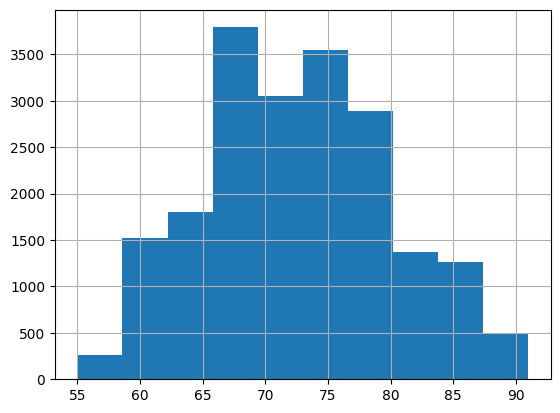

In [ ]:
df['text'].str.len().hist()


In [ ]:
pd.crosstab(df['intent'],df['sentiment'])

sentiment,Angry,Happy,Neutral
intent,,,
Billing,808,0,3167
Complaint,2417,0,1603
Product Inquiry,0,1161,2845
Refund,773,0,3173
Technical,811,0,3242


STEP 3 — Intent Classification (Fine Tuning)

Use:

HuggingFace

DistilBERT

FULL working training code for your 20,000 dataset 💯

In [ ]:
#Step 1: Install Libraries

In [ ]:
!pip install -U transformers datasets accelerate ## using huggingface model libray


In [ ]:
#!pip install -U datasets pyarrow

In [ ]:
#Step 2: Import Libraries

In [ ]:
import pandas as pd
import torch
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [ ]:
#Step 3: Load Your Dataset (20000 No Duplicates)

In [ ]:
df.shape

(20000, 3)

In [ ]:
df

,text,intent,sentiment
0,Ticket TKT56b634e7: Very frustrated with ZENDO...,Complaint,Angry
1,Ticket TKTe58a13e2: My ZENDSmart Traffic servi...,Technical,Neutral
2,Refund request TKTb5e109ba: I want refund for ...,Refund,Neutral
3,Refund request TKT16095b96: I want refund for ...,Refund,Angry
4,Issue ID TKTe7f95c79: Facing problem with ZEND...,Technical,Angry
...,...,...,...
19995,Complaint TKT3d4fe234: I am disappointed with ...,Complaint,Angry
19996,Invoice INV2d530f49: I was charged extra for m...,Billing,Neutral
19997,Ticket TKT679b48d7: My ZENDStorage 10TB servic...,Technical,Neutral
19998,Invoice INVf9e20d54: I was charged extra for m...,Billing,Neutral


In [ ]:
#Step 4: Encode Labels

In [ ]:
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['intent'])


In [ ]:
#Step 5: Train Test Split

In [ ]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['text'],
    df['label'],
    test_size=0.2,
    random_state=42
)


In [ ]:
df.columns

Index(['text', 'intent', 'sentiment', 'label'], dtype='object')

In [ ]:
#Step 6: Convert to HuggingFace Dataset

In [ ]:
train_dataset = Dataset.from_dict({
    "text": train_texts.tolist(),
    "label": train_labels.tolist()
})

val_dataset = Dataset.from_dict({
    "text": val_texts.tolist(),
    "label": val_labels.tolist()
})


In [ ]:
#Step 7: Load Tokenizer

In [ ]:
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
tokenizer

BertTokenizer(name_or_path='distilbert-base-uncased', vocab_size=30522, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
})

In [ ]:
#Step 8: Tokenization

In [ ]:
def tokenize_function(example):
    return tokenizer(
        example["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)

train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])
val_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])


Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

In [ ]:
#Step 9: Load Model

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(label_encoder.classes_)
)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
#Step 10: Training Arguments (UPDATED WORKING VERSION)

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./intent_model",

    eval_strategy="epoch",      # add this
    save_strategy="epoch",      # must match above
    load_best_model_at_end=True,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3
)


In [ ]:
training_args

TrainingArguments(
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
enable_jit_checkpoint=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
eval_strategy=IntervalStrategy.EPOCH,
eval_use_gather_object=Fals

In [ ]:
#Step 11: Trainer

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset
)


In [ ]:
trainer

In [ ]:
#Step 12: Train

In [ ]:
trainer.train()


Epoch,Training Loss,Validation Loss
1,0.000011,0.000004
2,0.000005,0.000002
3,0.000004,0.000002


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=3000, training_loss=8.924774476327003e-06, metrics={'train_runtime': 682.9527, 'train_samples_per_second': 70.283, 'train_steps_per_second': 4.393, 'total_flos': 1589693829120000.0, 'train_loss': 8.924774476327003e-06, 'epoch': 3.0})

In [ ]:
#💻 STEP 12 — Evaluate

In [ ]:
trainer.evaluate()

RuntimeError: on_train_begin must be called before on_evaluate

In [ ]:
#🚀 After Training – Save Model

In [ ]:
trainer.save_model("zends_intent_model")
tokenizer.save_pretrained("zends_intent_model")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('zends_intent_model/tokenizer_config.json',
 'zends_intent_model/tokenizer.json')

In [ ]:
!zip -r zends_intent_model.zip zends_intent_model


  adding: zends_intent_model/ (stored 0%)
  adding: zends_intent_model/config.json (deflated 54%)
  adding: zends_intent_model/tokenizer.json (deflated 71%)
  adding: zends_intent_model/tokenizer_config.json (deflated 42%)
  adding: zends_intent_model/model.safetensors (deflated 8%)
  adding: zends_intent_model/training_args.bin (deflated 53%)


In [ ]:
from transformers import pipeline

sentiment_model = pipeline("sentiment-analysis")

sentiment_model("I am very frustrated with your service")


No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

[{'label': 'NEGATIVE', 'score': 0.9996931552886963}]

In [ ]:
from google.colab import drive
drive.mount('/content/drive')